In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings("ignore")
print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [ ]:
from google.colab import files
import io

print("📂 Step 1 — Please select  'zoo-data.csv'  from your PC...")
uploaded1 = files.upload()
zoo_filename = list(uploaded1.keys())[0]
zoo = pd.read_csv(io.BytesIO(uploaded1[zoo_filename]))
print(f"✅ '{zoo_filename}' loaded! Shape: {zoo.shape}")

print("\n📂 Step 2 — Please select  'zoo-class_type.csv'  from your PC...")
uploaded2 = files.upload()
class_filename = list(uploaded2.keys())[0]
class_df = pd.read_csv(io.BytesIO(uploaded2[class_filename]))
print(f"✅ '{class_filename}' loaded! Shape: {class_df.shape}")

📂 Step 1 — Please select  'zoo-data.csv'  from your PC...


Saving zoo-data.csv to zoo-data (1).csv
✅ 'zoo-data (1).csv' loaded! Shape: (101, 18)

📂 Step 2 — Please select  'zoo-class_type.csv'  from your PC...


Saving zoo-class-type.csv to zoo-class-type (1).csv
✅ 'zoo-class-type (1).csv' loaded! Shape: (7, 4)


In [ ]:
print("=" * 55)
print("  ZOO DATA — First 5 Rows")
print("=" * 55)
print(zoo.head())

print("\n" + "=" * 55)
print("  CLASS TYPE FILE")
print("=" * 55)
print(class_df)

  ZOO DATA — First 5 Rows
  animal_name  hair  feathers  eggs  milk  airborne  aquatic  predator  \
0    aardvark     1         0     0     1         0        0         1   
1    antelope     1         0     0     1         0        0         0   
2        bass     0         0     1     0         0        1         1   
3        bear     1         0     0     1         0        0         1   
4        boar     1         0     0     1         0        0         1   

   toothed  backbone  breathes  venomous  fins  legs  tail  domestic  catsize  \
0        1         1         1         0     0     4     0         0        1   
1        1         1         1         0     0     4     1         0        1   
2        1         1         0         0     1     0     1         0        0   
3        1         1         1         0     0     4     0         0        1   
4        1         1         1         0     0     4     1         0        1   

   class_type  
0           1  
1         

In [ ]:
print("=" * 55)
print("  ZOO DATASET INFO")
print("=" * 55)
zoo.info()

print("\n" + "=" * 55)
print("  MISSING VALUES")
print("=" * 55)
print(zoo.isnull().sum())

print("\n" + "=" * 55)
print("  CLASS TYPE DISTRIBUTION")
print("=" * 55)
print(zoo['class_type'].value_counts())

print("\n" + "=" * 55)
print("  STATISTICAL SUMMARY")
print("=" * 55)
print(zoo.describe())

  ZOO DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   animal_name  101 non-null    object
 1   hair         101 non-null    int64 
 2   feathers     101 non-null    int64 
 3   eggs         101 non-null    int64 
 4   milk         101 non-null    int64 
 5   airborne     101 non-null    int64 
 6   aquatic      101 non-null    int64 
 7   predator     101 non-null    int64 
 8   toothed      101 non-null    int64 
 9   backbone     101 non-null    int64 
 10  breathes     101 non-null    int64 
 11  venomous     101 non-null    int64 
 12  fins         101 non-null    int64 
 13  legs         101 non-null    int64 
 14  tail         101 non-null    int64 
 15  domestic     101 non-null    int64 
 16  catsize      101 non-null    int64 
 17  class_type   101 non-null    int64 
dtypes: int64(17), object(1)
memory usage: 14.3+ KB

  M

In [ ]:
class_map = {
    1: 'Mammal',
    2: 'Bird',
    3: 'Reptile',
    4: 'Fish',
    5: 'Amphibian',
    6: 'Bug',
    7: 'Invertebrate'
}

# Try to extract names from class_df if it has them
try:
    # Common column names in zoo-class_type.csv
    if 'Class_Type' in class_df.columns and 'Class_Number' in class_df.columns:
        class_map = dict(zip(class_df['Class_Number'], class_df['Class_Type']))
    elif 'class_type' in class_df.columns and 'class_number' in class_df.columns:
        class_map = dict(zip(class_df['class_number'], class_df['class_type']))
    print("✅ Class labels loaded from zoo-class_type.csv")
except:
    print("ℹ️  Using default class labels (Mammal, Bird, Reptile...)")

zoo['class_label'] = zoo['class_type'].map(class_map)
print("\nClass distribution with labels:")
print(zoo['class_label'].value_counts())

✅ Class labels loaded from zoo-class_type.csv

Class distribution with labels:
class_label
Mammal          41
Bird            20
Fish            13
Invertebrate    10
Bug              8
Reptile          5
Amphibian        4
Name: count, dtype: int64


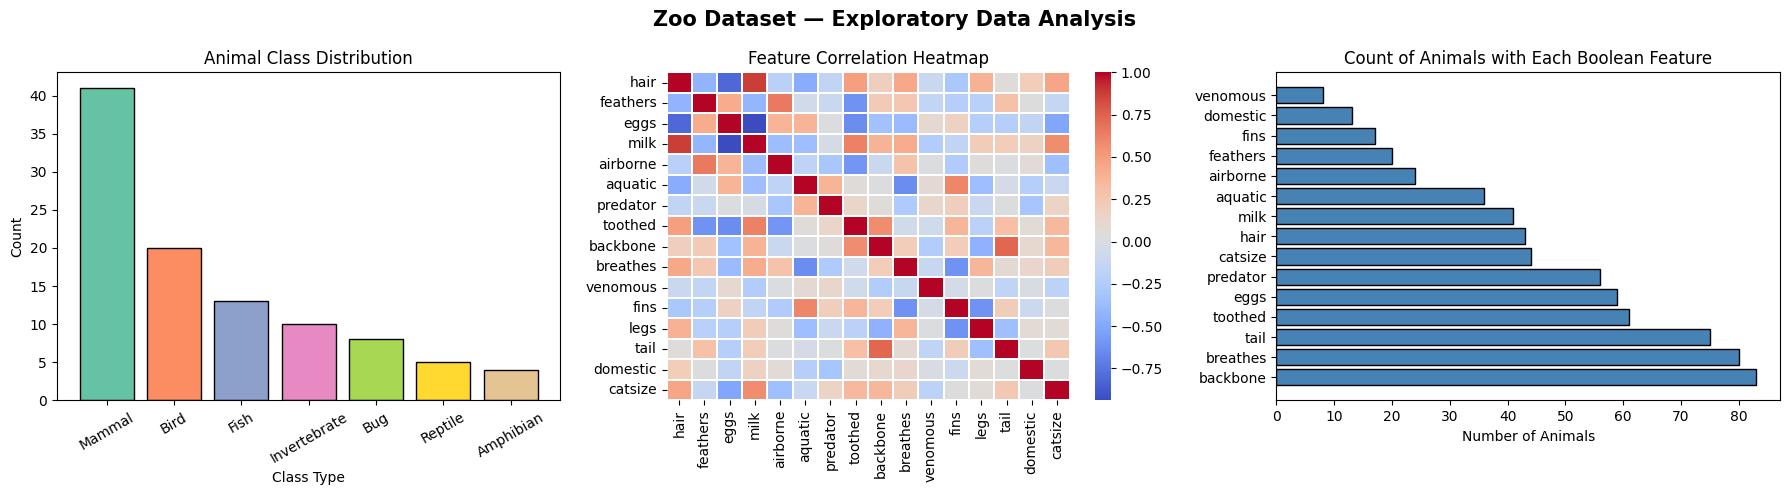

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Zoo Dataset — Exploratory Data Analysis",
             fontsize=15, fontweight='bold')

# 1. Class type distribution
class_counts = zoo['class_label'].value_counts()
axes[0].bar(class_counts.index, class_counts.values,
            color=sns.color_palette('Set2', len(class_counts)), edgecolor='black')
axes[0].set_title("Animal Class Distribution")
axes[0].set_xlabel("Class Type")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=30)

# 2. Feature correlation heatmap
num_zoo = zoo.drop(columns=['animal_name', 'class_type', 'class_label'],
                   errors='ignore').select_dtypes(include=np.number)
sns.heatmap(num_zoo.corr(), cmap='coolwarm', ax=axes[1],
            linewidths=0.3, annot=False)
axes[1].set_title("Feature Correlation Heatmap")

# 3. Boolean features — how many animals have each feature
bool_cols = [c for c in num_zoo.columns if num_zoo[c].nunique() == 2]
feat_sums = num_zoo[bool_cols].sum().sort_values(ascending=False)
axes[2].barh(feat_sums.index, feat_sums.values,
             color='steelblue', edgecolor='black')
axes[2].set_title("Count of Animals with Each Boolean Feature")
axes[2].set_xlabel("Number of Animals")

plt.tight_layout()
plt.show()

In [ ]:
drop_cols = ['animal_name', 'class_label']
df_model = zoo.drop(columns=[c for c in drop_cols if c in zoo.columns])

# Features and Target
target   = 'class_type'
features = [c for c in df_model.columns if c != target]

X = df_model[features]
y = df_model[target]

print("✅ Features used:", features)
print(f"\n   X shape : {X.shape}")
print(f"   y shape : {y.shape}")
print(f"\n   Classes : {sorted(y.unique())}  →  {[class_map.get(i, i) for i in sorted(y.unique())]}")

# Check if any preprocessing needed (already binary features mostly)
print("\n✅ Data types:")
print(X.dtypes.value_counts())
print("\n✅ No missing values:", X.isnull().sum().sum() == 0)

✅ Features used: ['hair', 'feathers', 'eggs', 'milk', 'airborne', 'aquatic', 'predator', 'toothed', 'backbone', 'breathes', 'venomous', 'fins', 'legs', 'tail', 'domestic', 'catsize']

   X shape : (101, 16)
   y shape : (101,)

   Classes : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]  →  ['Mammal', 'Bird', 'Reptile', 'Fish', 'Amphibian', 'Bug', 'Invertebrate']

✅ Data types:
int64    16
Name: count, dtype: int64

✅ No missing values: True


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training samples : {X_train.shape[0]}")
print(f"Testing  samples : {X_test.shape[0]}")

Training samples : 80
Testing  samples : 21


In [ ]:
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)
print("✅ Features scaled using StandardScaler")

✅ Features scaled using StandardScaler


In [ ]:
model = LogisticRegression(
    multi_class='multinomial',   # Softmax for multiclass
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)
model.fit(X_train, y_train)
print("✅ Multiclass Logistic Regression (Softmax) model trained!")

✅ Multiclass Logistic Regression (Softmax) model trained!


In [ ]:
y_pred = model.predict(X_test)
acc    = accuracy_score(y_test, y_pred)

print("=" * 55)
print(f"  Accuracy : {acc:.4f}  ({acc*100:.2f}%)")
print("=" * 55)

label_names = [class_map.get(i, str(i)) for i in sorted(y.unique())]
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_names))

  Accuracy : 1.0000  (100.00%)

Classification Report:
              precision    recall  f1-score   support

      Mammal       1.00      1.00      1.00         8
        Bird       1.00      1.00      1.00         4
     Reptile       1.00      1.00      1.00         1
        Fish       1.00      1.00      1.00         3
   Amphibian       1.00      1.00      1.00         1
         Bug       1.00      1.00      1.00         2
Invertebrate       1.00      1.00      1.00         2

    accuracy                           1.00        21
   macro avg       1.00      1.00      1.00        21
weighted avg       1.00      1.00      1.00        21



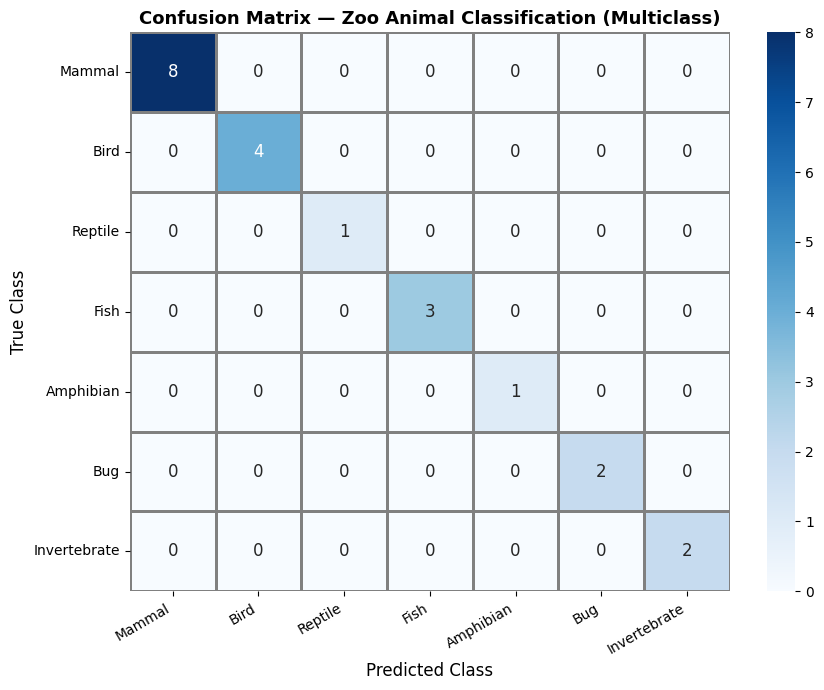


📊 Per-Class Correct Predictions:
   Mammal          : 8/8  (100.0%)
   Bird            : 4/4  (100.0%)
   Reptile         : 1/1  (100.0%)
   Fish            : 3/3  (100.0%)
   Amphibian       : 1/1  (100.0%)
   Bug             : 2/2  (100.0%)
   Invertebrate    : 2/2  (100.0%)


In [ ]:
cm = confusion_matrix(y_test, y_pred, labels=sorted(y.unique()))

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names,
            yticklabels=label_names,
            linewidths=0.8, linecolor='gray',
            annot_kws={"size": 12})
plt.title("Confusion Matrix — Zoo Animal Classification (Multiclass)",
          fontsize=13, fontweight='bold')
plt.xlabel("Predicted Class", fontsize=12)
plt.ylabel("True Class", fontsize=12)
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
# Per-class accuracy from confusion matrix
print("\n📊 Per-Class Correct Predictions:")
for i, label in enumerate(label_names):
    total = cm[i].sum()
    correct = cm[i][i]
    if total > 0:
        print(f"   {label:<15} : {correct}/{total}  ({correct/total*100:.1f}%)")

In [ ]:
y_proba = model.predict_proba(X_test)
proba_df = pd.DataFrame(y_proba, columns=label_names)

print("Sample prediction probabilities (first 5 test samples):")
print(proba_df.head().round(3))

Sample prediction probabilities (first 5 test samples):
   Mammal   Bird  Reptile   Fish  Amphibian    Bug  Invertebrate
0   0.043  0.016    0.055  0.026      0.773  0.071         0.016
1   0.002  0.977    0.010  0.002      0.001  0.007         0.001
2   0.006  0.005    0.014  0.958      0.009  0.000         0.007
3   0.005  0.982    0.004  0.003      0.003  0.002         0.001
4   0.991  0.001    0.006  0.000      0.001  0.000         0.000


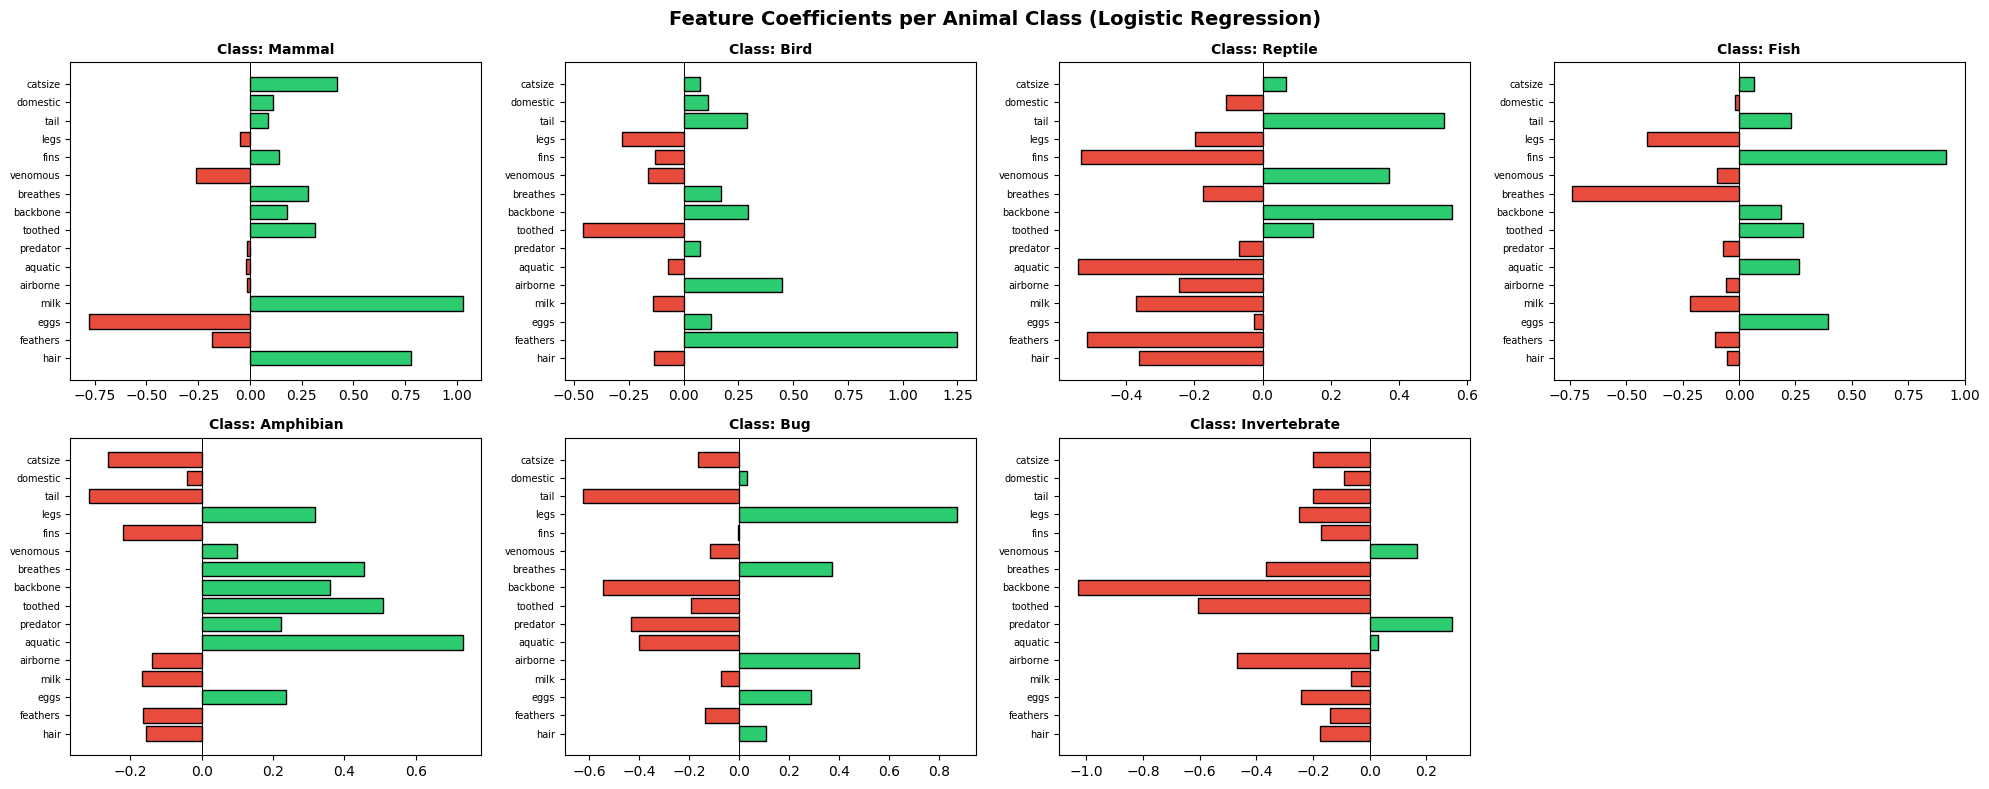


✅ Lab-3 Task 2 Complete — Multiclass Logistic Regression on Zoo Dataset!


In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
fig.suptitle("Feature Coefficients per Animal Class (Logistic Regression)",
             fontsize=14, fontweight='bold')
axes = axes.flatten()

for idx, (class_id, label) in enumerate(class_map.items()):
    if idx >= len(model.coef_):
        break
    coef = model.coef_[idx]
    colors = ['#e74c3c' if c < 0 else '#2ecc71' for c in coef]
    axes[idx].barh(features, coef, color=colors, edgecolor='black')
    axes[idx].axvline(0, color='black', linewidth=0.7)
    axes[idx].set_title(f"Class: {label}", fontsize=10, fontweight='bold')
    axes[idx].tick_params(axis='y', labelsize=7)

# Hide unused subplot
for j in range(idx+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

print("\n✅ Lab-3 Task 2 Complete — Multiclass Logistic Regression on Zoo Dataset!")